# Scaled Dot-Product Attention

这是 Attention 机制的核心计算。

## 公式

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

其中：
- $Q$ (Query): 查询向量
- $K$ (Key): 键向量
- $V$ (Value): 值向量
- $d_k$: Key 的维度
- $\sqrt{d_k}$: 缩放因子，防止点积过大导致 softmax 梯度消失

In [2]:
import torch
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子
torch.manual_seed(42)

## 1. 从零实现 Scaled Dot-Product Attention

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention
    
    Args:
        Q: Query, shape [batch_size, seq_len_q, d_k]
        K: Key, shape [batch_size, seq_len_k, d_k]
        V: Value, shape [batch_size, seq_len_k, d_v]
        mask: Optional mask
    
    Returns:
        output: shape [batch_size, seq_len_q, d_v]
        attention_weights: shape [batch_size, seq_len_q, seq_len_k]
    """
    d_k = Q.size(-1)
    
    # 步骤 1: 计算 Q @ K^T
    scores = torch.matmul(Q, K.transpose(-2, -1))
    print(f"QK^T shape: {scores.shape}")
    
    # 步骤 2: 缩放
    scores = scores / math.sqrt(d_k)
    print(f"Scaled scores range: [{scores.min():.2f}, {scores.max():.2f}]")
    
    # 步骤 3: 应用 mask (可选)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # 步骤 4: Softmax
    attention_weights = F.softmax(scores, dim=-1)
    print(f"Attention weights shape: {attention_weights.shape}")
    print(f"Attention weights sum: {attention_weights.sum(dim=-1)[0, 0]:.4f} (应该为 1.0)")
    
    # 步骤 5: 加权求和
    output = torch.matmul(attention_weights, V)
    print(f"Output shape: {output.shape}")
    
    return output, attention_weights

## 2. 简单示例

In [4]:
# 创建简单的输入
batch_size = 1
seq_len = 4
d_k = 8

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

print("输入:")
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print("\n计算过程:")

output, attn_weights = scaled_dot_product_attention(Q, K, V)

输入:
Q shape: torch.Size([1, 4, 8])
K shape: torch.Size([1, 4, 8])
V shape: torch.Size([1, 4, 8])

计算过程:
QK^T shape: torch.Size([1, 4, 4])
Scaled scores range: [-3.06, 1.53]
Attention weights shape: torch.Size([1, 4, 4])
Attention weights sum: 1.0000 (应该为 1.0)
Output shape: torch.Size([1, 4, 8])


## 3. 可视化注意力权重

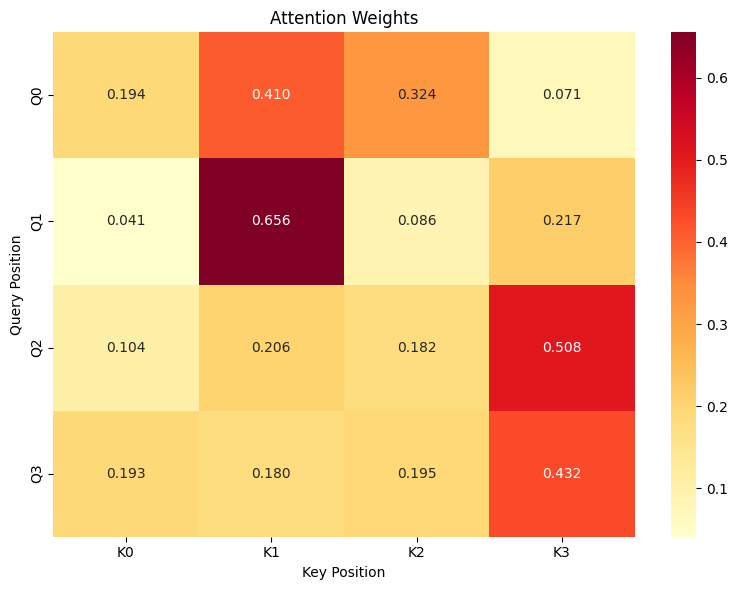


解释:
- 每一行代表一个 Query 对所有 Key 的注意力分布
- 每一行的和为 1.0
- 颜色越深表示注意力权重越大


In [5]:
# 可视化注意力权重
plt.figure(figsize=(8, 6))
sns.heatmap(attn_weights[0].detach().numpy(), 
            annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[f'K{i}' for i in range(seq_len)],
            yticklabels=[f'Q{i}' for i in range(seq_len)])
plt.title('Attention Weights')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.tight_layout()
plt.show()

print("\n解释:")
print("- 每一行代表一个 Query 对所有 Key 的注意力分布")
print("- 每一行的和为 1.0")
print("- 颜色越深表示注意力权重越大")

## 4. 总结

### Scaled Dot-Product Attention 的关键点：

1. **计算相似度**: $QK^T$ 计算 Query 和 Key 的相似度
2. **缩放**: 除以 $\sqrt{d_k}$ 防止梯度消失
3. **Mask**: 可选的 mask 用于控制注意力范围
4. **归一化**: Softmax 将分数转换为概率分布
5. **加权求和**: 用注意力权重对 Value 加权求和

### 下一步：
- `02_multi_head_attention.ipynb`: 学习 Multi-Head Attention
- `03_grouped_query_attention.ipynb`: 学习 GQA
- `04_kv_cache.ipynb`: 学习 KV Cache 优化